# Notebook 05 — Transfer Learning and Fine-Tuning

**Project:** Cat vs Dog Image Classification: A Comparative Deep Learning Study

## 1. Notebook Goal

Notebook 04's best from-scratch model was the **Combined Regularized CNN**
(augmentation + BatchNorm + Dropout + one extra conv block): **91.55%** validation accuracy,
**0.2018** validation loss, **3,044,801** parameters.

This notebook asks: **can a pretrained ImageNet backbone (MobileNetV2) beat that, using far fewer
trainable parameters?** Two stages:

- **Stage 1 — Frozen transfer learning:** MobileNetV2's convolutional backbone is frozen; only a
  small classification head is trained on top of its pretrained features.
- **Stage 2 — Fine-tuning:** the later part of the backbone is unfrozen and trained with a very
  small learning rate, to let it adapt those features specifically to cats vs dogs.

**As in every previous notebook: the test set is never used here.** Only train/validation.


## 2. Imports and Configuration

**What are we doing?** Importing what we need and fixing the same seed used in every previous
notebook.


In [17]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

MANIFEST_PATH = Path("clean_manifest.csv")
IMG_SIZE = (180, 180)
BATCH_SIZE = 32
EPOCHS = 15

print("TensorFlow version:", tf.__version__)
print("Seed:", SEED)
print("Image size:", IMG_SIZE, "| Batch size:", BATCH_SIZE)


TensorFlow version: 2.21.0
Seed: 42
Image size: (180, 180) | Batch size: 32


## 3. Recreate Official Train/Validation Split

**What are we doing?** Loading `clean_manifest.csv` and recreating the exact same 80/10/10
stratified split used in every previous notebook, with the same seed.

**Why are we doing it?** A fair comparison against the Notebook 03/04 models requires training and
validating on the exact same data they used.


In [18]:
manifest_df = pd.read_csv(MANIFEST_PATH)

assert len(manifest_df) == 24_966, f"Expected 24,966 manifest rows, got {len(manifest_df)}"
assert (manifest_df["class_name"] == "Cat").sum() == 12_480, "Cat count does not match the official audit"
assert (manifest_df["class_name"] == "Dog").sum() == 12_486, "Dog count does not match the official audit"

train_df, temp_df = train_test_split(
    manifest_df, test_size=0.2, stratify=manifest_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

assert len(train_df) == 19_972, f"Expected 19,972 training rows, got {len(train_df)}"
assert len(val_df) == 2_497, f"Expected 2,497 validation rows, got {len(val_df)}"
assert len(test_df) == 2_497, f"Expected 2,497 test rows, got {len(test_df)}"

train_paths = set(train_df["filepath"])
val_paths = set(val_df["filepath"])
test_paths = set(test_df["filepath"])
assert train_paths.isdisjoint(val_paths), "Train/validation overlap found"
assert train_paths.isdisjoint(test_paths), "Train/test overlap found"
assert val_paths.isdisjoint(test_paths), "Validation/test overlap found"

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df), "(test set held out, not used below)")


Train: 19972 | Val: 2497 | Test: 2497 (test set held out, not used below)


## 4. Data Pipeline

**What are we doing?** Rebuilding `train_ds` and `val_ds` -- JPEG decode, resize to 180x180, batch,
prefetch. Same as Notebooks 02-04.

**Important difference from Notebook 03/04:** there is **no** `Rescaling(1./255)` here. MobileNetV2
expects its own specific preprocessing (Section 6), which scales pixels differently ([-1, 1], not
[0, 1]). Applying both would double-preprocess the images and feed the network the wrong pixel
range, so we deliberately leave pixel scaling out of the pipeline and out of this stage entirely --
it happens once, inside the model, in Section 6.

**We do not build a `test_ds`.** The test set stays untouched.


In [19]:
def load_image(filepath, label):
    image = tf.io.read_file(filepath)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    return image, label


def make_dataset(split_df, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((split_df["filepath"].values, split_df["label"].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(split_df), seed=SEED)
    ds = ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df)

images, labels = next(iter(train_ds))
assert images.shape[1:] == (180, 180, 3), f"Unexpected image shape: {images.shape}"
print("Batch shape:", images.shape)
print("'test_ds' created in this notebook:", "test_ds" in dir())


Batch shape: (32, 180, 180, 3)
'test_ds' created in this notebook: False


## 5. Data Augmentation

**What are we doing?** Reusing the exact same augmentation block from Notebook 04, so the transfer
learning experiments stay reasonably comparable to the Combined Regularized CNN.

**Why as model layers, not `.map()`?** Same reason as Notebook 04: Keras augmentation layers are
automatically active only during training and automatically become no-ops during
`evaluate()`/`predict()`, so validation data is never augmented without needing a second pipeline.


In [20]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ],
    name="data_augmentation",
)


## 6. MobileNetV2 Backbone

**What are we doing?** Loading MobileNetV2, pretrained on ImageNet, without its original
classification head (`include_top=False`), and freezing it for now.

**Why MobileNetV2?** It's small and fast enough to be practical on CPU, while still providing
genuinely useful pretrained visual features -- the same reasoning used when this model was chosen
for the project back in the planning stage.

**On preprocessing:** MobileNetV2 was trained with pixels scaled to **[-1, 1]** by
`tf.keras.applications.mobilenet_v2.preprocess_input` -- a different range than the
`Rescaling(1./255)` used in Notebooks 03-04 (which scales to [0, 1]). We use MobileNetV2's own
preprocessing function here instead, applied once, directly in the model -- not both.

**On the input size:** 180x180 is not one of the standard ImageNet input resolutions commonly
associated with MobileNetV2. Keras may issue a warning about the input size. We keep 180x180 to
maintain consistency with the previous notebooks. Because `include_top=False` is used, the
convolutional backbone can operate with different spatial input resolutions.


In [21]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(180, 180, 3),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

print("MobileNetV2 backbone loaded with ImageNet weights.")
print("Backbone layers:", len(base_model.layers))
print("Backbone total parameters:", base_model.count_params())
print("Backbone trainable parameters (should be 0, frozen):", 
      sum(tf.size(w).numpy() for w in base_model.trainable_weights))


ipykernel_40452\245943830.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


MobileNetV2 backbone loaded with ImageNet weights.
Backbone layers: 154
Backbone total parameters: 2257984
Backbone trainable parameters (should be 0, frozen): 0


**A note on the `UserWarning` printed above:**

Running the cell above prints something like:

> `UserWarning: input_shape is undefined or non-square, or rows is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.`

This is expected, and it is **not an error** or a sign that pretrained weights failed to load. Here is exactly what is happening:

- **Framework / implementation:** this is TensorFlow's Keras Applications implementation of MobileNetV2 (`tf.keras.applications.MobileNetV2`), the official ImageNet-pretrained model shipped with Keras -- not a custom or third-party implementation.
- **Why the warning fires:** Keras only ships ImageNet-pretrained weights for a small, fixed set of input resolutions (96, 128, 160, 192, 224). Our `input_shape=(180, 180, 3)` is not one of them, so Keras cannot match it to a resolution-specific checkpoint, warns about it, and falls back to loading the one set of ImageNet weights it has (associated with 224x224).
- **Are the ImageNet weights actually loaded and used correctly at 180x180?** Yes. Because `include_top=False` drops MobileNetV2's original 224x224-specific classification head, all we keep is the convolutional backbone -- and that backbone is fully convolutional: every learned filter is a small spatial kernel applied the same way regardless of the input's overall height/width. The *same* ImageNet-trained filters are applied correctly at 180x180 without any resizing or retraining of the weights themselves. `GlobalAveragePooling2D` (Section 7) then adapts automatically to whatever spatial map size 180x180 produces. The printed `Backbone total parameters` count above confirms the full ImageNet weight set was loaded (it matches the standard MobileNetV2 parameter count).
- **What we deliberately did *not* do:** we did not change `IMG_SIZE` to 224x224 just to silence this warning, and we did not retrain or re-architect anything. `IMG_SIZE=(180, 180)` is a fixed project-wide parameter shared with Notebooks 01-04, and changing it here would break that consistency for no real benefit -- the warning is purely informational for this use case, not a sign of a real problem.


## 7. Stage 1 — Frozen Transfer Learning

**What are we doing?** Building the full model: input -> augmentation -> MobileNetV2 preprocessing
-> frozen MobileNetV2 backbone -> `GlobalAveragePooling2D` -> `Dropout` -> `Dense(1, sigmoid)`. Only
the small head is trainable in this stage.

**Why `GlobalAveragePooling2D` instead of `Flatten`?** MobileNetV2's last feature map has many
channels; flattening it would create a huge, parameter-heavy dense layer. Global average pooling
collapses each channel to a single number, keeping the head small and parameter-efficient -- exactly
the point of using a pretrained backbone.

**Why `base_model(x, training=False)`?** MobileNetV2 contains BatchNormalization layers. Passing
`training=False` keeps their running statistics fixed during the forward pass regardless of the
model's overall training mode -- important now, and doubly important in Stage 2 once part of the
backbone is unfrozen.

**Why a smaller patience here than Notebook 04?** Notebook 04 used `patience=15` deliberately, to
see the *entire* 15-epoch curve for every from-scratch experiment. Here we want genuine early
stopping -- if the frozen head converges early (which is common for transfer learning), we let it
stop rather than forcing 15 epochs.We use `patience=3`, a much smaller value than Notebook 03's baseline (patience=15).

In [22]:
inputs = tf.keras.Input(shape=(180, 180, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

frozen_model = tf.keras.Model(inputs, outputs, name="frozen_mobilenetv2")
frozen_model.summary()


Model: "frozen_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 6, 6, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [23]:
def count_trainable_params(model):
    return int(sum(tf.size(w).numpy() for w in model.trainable_weights))


def get_val_predictions(model, val_ds, threshold=0.5):
    """Predictions from val_ds using the model's current (best-restored) weights."""
    y_true, y_prob = [], []
    for images, labels in val_ds:
        probs = model.predict(images, verbose=0).ravel()
        y_true.extend(labels.numpy())
        y_prob.extend(probs)
    y_true = np.array(y_true)
    y_pred = (np.array(y_prob) >= threshold).astype(int)
    return y_true, y_pred


def run_transfer_experiment(model, name, filename, learning_rate, epochs=EPOCHS, patience=3, notes=""):
    """Compile, train, time, and evaluate one transfer-learning stage.

    Best validation loss and best validation accuracy are tracked independently (same convention
    as Notebook 04). Precision/Recall/F1 are computed after `restore_best_weights=True` has already
    restored the best-val-loss weights, so they correspond to that same checkpoint.
    """
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    early_stopping = callbacks.EarlyStopping(
        monitor="val_loss", patience=patience, restore_best_weights=True
    )
    checkpoint = callbacks.ModelCheckpoint(filename, monitor="val_loss", save_best_only=True)

    start_time = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        shuffle=False,
        callbacks=[early_stopping, checkpoint],
    )
    training_time_seconds = time.time() - start_time

    best_loss_index = int(np.argmin(history.history["val_loss"]))
    best_val_loss = float(history.history["val_loss"][best_loss_index])
    best_val_loss_epoch = best_loss_index + 1

    best_acc_index = int(np.argmax(history.history["val_accuracy"]))
    best_val_acc = float(history.history["val_accuracy"][best_acc_index])
    best_val_acc_epoch = best_acc_index + 1

    y_true, y_pred = get_val_predictions(model, val_ds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    result = {
        "Experiment": name,
        "Best Val Accuracy": round(best_val_acc, 4),
        "Best Val Accuracy Epoch": best_val_acc_epoch,
        "Best Val Loss": round(best_val_loss, 4),
        "Best Val Loss Epoch": best_val_loss_epoch,
        "Val Precision": round(float(precision), 4),
        "Val Recall": round(float(recall), 4),
        "Val F1": round(float(f1), 4),
        "Training Time (min)": round(training_time_seconds / 60, 2),
        "Trainable Parameters": count_trainable_params(model),
        "Total Parameters": model.count_params(),
        "Notes": notes,
    }

    return history, result


history_frozen, result_frozen = run_transfer_experiment(
    frozen_model,
    "Frozen MobileNetV2",
    "frozen_mobilenetv2.keras",
    learning_rate=1e-3,
    notes="Backbone fully frozen; only GAP+Dropout+Dense head trained.",
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 290s 453ms/step - accuracy: 0.9497 - loss: 0.1246 - val_accuracy: 0.9832 - val_loss: 0.0521
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 300s 479ms/step - accuracy: 0.9681 - loss: 0.0836 - val_accuracy: 0.9796 - val_loss: 0.0509
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 299s 478ms/step - accuracy: 0.9692 - loss: 0.0828 - val_accuracy: 0.9824 - val_loss: 0.0492
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 294s 470ms/step - accuracy: 0.9701 - loss: 0.0798 - val_accuracy: 0.9840 - val_loss: 0.0443
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 298s 476ms/step - accuracy: 0.9701 - loss: 0.0780 - val_accuracy: 0.9784 - val_loss: 0.0534
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 238s 380ms/step - accuracy: 0.9715 - loss: 0.0760 - val_accuracy: 0.9848 - val_loss: 0.0433
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 372ms/step - accuracy: 0.9711 - loss: 0.0758 - val_accuracy: 0.9824 - val_loss: 0.0478
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 246s 393ms/step - accuracy: 0.9714 -

## 8. Stage 1 Results


In [24]:
pd.Series(result_frozen, name="Value").to_frame()


,Value
Experiment,Frozen MobileNetV2
Best Val Accuracy,0.9892
Best Val Accuracy Epoch,8
Best Val Loss,0.0419
Best Val Loss Epoch,8
Val Precision,0.9927
Val Recall,0.9856
Val F1,0.9892
Training Time (min),48.65
Trainable Parameters,1281


## 9. Stage 2 — Fine-Tuning

**What are we doing?** Starting from the Stage 1 model (already holding its best, restored
weights), unfreezing only the **last 30 layers** of MobileNetV2, and continuing training with a
much smaller learning rate.

**Why unfreeze only the last 30 layers, not the whole backbone?** Earlier layers of a pretrained
network learn very generic features (edges, textures, colors) that are useful for almost any image
task, including this one. Later layers learn more task-specific patterns. Fine-tuning only the
later layers adapts those task-specific features to cats/dogs, while keeping the generic early
features intact -- and is far cheaper to train.

**Why keep BatchNormalization layers frozen even within the unfrozen tail?** Fine-tuning would
otherwise update BatchNorm's running statistics using our (relatively small, 32-image) batches,
which can destabilize training. We explicitly keep every BatchNorm layer's `trainable` flag `False`,
even among the layers we're otherwise unfreezing.

**Why a much smaller learning rate (`1e-5` vs `1e-3`)?** The backbone's pretrained weights are
already useful. A large learning rate applied to them could overwrite that useful pretrained
information with large, disruptive updates. A small learning rate makes small, careful adjustments
instead.


In [25]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
print(f"Freezing the first {fine_tune_at} of {len(base_model.layers)} backbone layers.")
print(f"Unfreezing the last {len(base_model.layers) - fine_tune_at} layers (except BatchNorm).")

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

bn_kept_frozen = 0
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
        bn_kept_frozen += 1

print(f"BatchNormalization layers kept frozen within the unfrozen tail: {bn_kept_frozen}")


Freezing the first 124 of 154 backbone layers.
Unfreezing the last 30 layers (except BatchNorm).
BatchNormalization layers kept frozen within the unfrozen tail: 11


In [26]:
history_finetuned, result_finetuned = run_transfer_experiment(
    frozen_model,  # same model object, continuing from its Stage 1 (best-restored) weights
    "Fine-Tuned MobileNetV2",
    "finetuned_mobilenetv2.keras",
    learning_rate=1e-5,
    notes="Last 30 backbone layers unfrozen (BatchNorm layers kept frozen); continued from Stage 1 weights.",
)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 323s 495ms/step - accuracy: 0.9723 - loss: 0.0702 - val_accuracy: 0.9820 - val_loss: 0.0467
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 412s 658ms/step - accuracy: 0.9760 - loss: 0.0616 - val_accuracy: 0.9852 - val_loss: 0.0399
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 411s 658ms/step - accuracy: 0.9796 - loss: 0.0563 - val_accuracy: 0.9860 - val_loss: 0.0367
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 386s 618ms/step - accuracy: 0.9795 - loss: 0.0524 - val_accuracy: 0.9872 - val_loss: 0.0364
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 387s 619ms/step - accuracy: 0.9819 - loss: 0.0474 - val_accuracy: 0.9864 - val_loss: 0.0367
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 414s 662ms/step - accuracy: 0.9823 - loss: 0.0453 - val_accuracy: 0.9868 - val_loss: 0.0362
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 391s 626ms/step - accuracy: 0.9837 - loss: 0.0414 - val_accuracy: 0.9868 - val_loss: 0.0350
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 384s 614ms/step - accuracy: 0.9877 -

## 10. Stage 2 Results


In [27]:
pd.Series(result_finetuned, name="Value").to_frame()


,Value
Experiment,Fine-Tuned MobileNetV2
Best Val Accuracy,0.9908
Best Val Accuracy Epoch,13
Best Val Loss,0.0323
Best Val Loss Epoch,10
Val Precision,0.9864
Val Recall,0.9904
Val F1,0.9884
Training Time (min),78.57
Trainable Parameters,1512001


## 11. Transfer Learning Comparison

**What are we doing?** Comparing Stage 1 (frozen) directly against Stage 2 (fine-tuned), before
bringing in the earlier from-scratch models.


In [28]:
transfer_comparison_df = pd.DataFrame([result_frozen, result_finetuned])[
    ["Experiment", "Best Val Accuracy", "Best Val Accuracy Epoch", "Best Val Loss",
     "Best Val Loss Epoch", "Val Precision", "Val Recall", "Val F1",
     "Training Time (min)", "Trainable Parameters", "Total Parameters", "Notes"]
]
transfer_comparison_df


,Experiment,Best Val Accuracy,Best Val Accuracy Epoch,Best Val Loss,Best Val Loss Epoch,Val Precision,Val Recall,Val F1,Training Time (min),Trainable Parameters,Total Parameters,Notes
0,Frozen MobileNetV2,0.9892,8,0.0419,8,0.9927,0.9856,0.9892,48.65,1281,2259265,Backbone fully frozen; only GAP+Dropout+Dense ...
1,Fine-Tuned MobileNetV2,0.9908,13,0.0323,10,0.9864,0.9904,0.9884,78.57,1512001,2259265,Last 30 backbone layers unfrozen (BatchNorm la...


## 12. Training Curves

**What are we doing?** Plotting training vs validation accuracy and loss for both stages.

**Why are we doing it?** The tables above give final numbers; these curves show whether each stage
converged smoothly, whether fine-tuning kept improving or started overfitting, and how the two
stages' training dynamics compare.


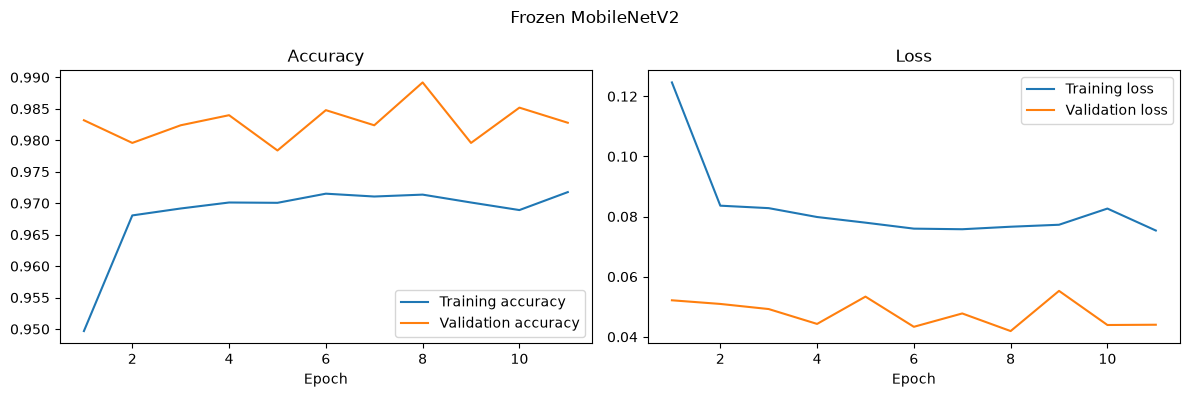

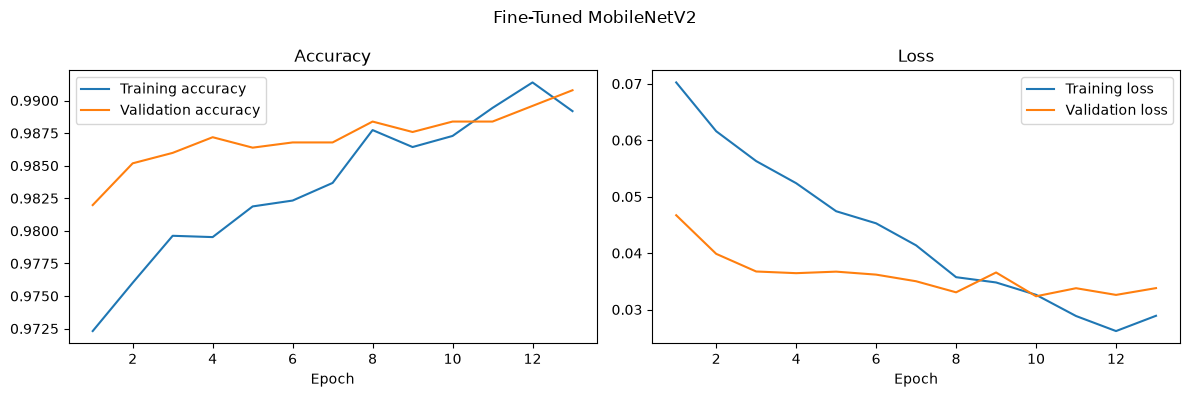

In [29]:
for name, history in [("Frozen MobileNetV2", history_frozen), ("Fine-Tuned MobileNetV2", history_finetuned)]:
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(name)

    axes[0].plot(epochs_range, acc, label="Training accuracy")
    axes[0].plot(epochs_range, val_acc, label="Validation accuracy")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_range, loss, label="Training loss")
    axes[1].plot(epochs_range, val_loss, label="Validation loss")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## 13. Comparison with Previous Models

**What are we doing?** Adding the established Notebook 03 and Notebook 04 results to build one
final comparison table across the whole project so far. These are **not retrained** here -- we use
their already-recorded results.

**Note on the Baseline row:** Notebook 03 did not compute Precision/Recall/F1, so those are
`NaN` for the baseline, not fabricated. For the Combined Regularized CNN, Notebook 04 reported a best validation accuracy of 0.9155
(epoch 14) and a best validation loss of 0.2018 (epoch 11) -- these occurred at *different*
epochs, so the two epoch columns differ for that row, unlike Notebook 04's other single-technique
experiments.


In [ ]:
baseline_cnn_reference = {
    "Experiment": "Baseline CNN (Notebook 03)",
    "Best Val Accuracy": 0.8230,
    "Best Val Accuracy Epoch": 6,
    "Best Val Loss": 0.3936,
    "Best Val Loss Epoch": 3,
    "Val Precision": np.nan,
    "Val Recall": np.nan,
    "Val F1": np.nan,
    "Training Time (min)": np.nan,
    "Trainable Parameters": 6_647_105,
    "Total Parameters": 6_647_105,
    "Notes": "Reference only, not retrained here. Strong overfitting observed (train acc ~99%).",
}

combined_cnn_reference = {
    "Experiment": "Combined Regularized CNN (Notebook 04)",
    "Best Val Accuracy": 0.9155,
    "Best Val Accuracy Epoch": 14,  # Notebook 04: best val accuracy and best val loss occurred at different epochs
    "Best Val Loss": 0.2018,
    "Best Val Loss Epoch": 11,
    "Val Precision": 0.9184,
    "Val Recall": 0.9103,
    "Val F1": 0.9144,
    "Training Time (min)": np.nan,
    "Trainable Parameters": 3_044_801,
    "Total Parameters": 3_044_801,
    "Notes": "Reference only, not retrained here. Best from-scratch model from Notebook 04.",
}

full_comparison_df = pd.DataFrame(
    [baseline_cnn_reference, combined_cnn_reference, result_frozen, result_finetuned]
)[
    ["Experiment", "Best Val Accuracy", "Best Val Accuracy Epoch", "Best Val Loss",
     "Best Val Loss Epoch", "Val Precision", "Val Recall", "Val F1",
     "Training Time (min)", "Trainable Parameters", "Total Parameters", "Notes"]
]
full_comparison_df = full_comparison_df.sort_values("Best Val Accuracy", ascending=False).reset_index(drop=True)
full_comparison_df


,Experiment,Best Val Accuracy,Best Val Accuracy Epoch,Best Val Loss,Best Val Loss Epoch,Val Precision,Val Recall,Val F1,Training Time (min),Trainable Parameters,Total Parameters,Notes
0,Fine-Tuned MobileNetV2,0.9908,13,0.0323,10,0.9864,0.9904,0.9884,78.57,1512001,2259265,Last 30 backbone layers unfrozen (BatchNorm la...
1,Frozen MobileNetV2,0.9892,8,0.0419,8,0.9927,0.9856,0.9892,48.65,1281,2259265,Backbone fully frozen; only GAP+Dropout+Dense ...
2,Combined Regularized CNN (Notebook 04),0.9155,14,0.2018,11,0.9184,0.9103,0.9144,NaN,3044801,3044801,"Reference only, not retrained here. Best from-..."
3,Baseline CNN (Notebook 03),0.8230,6,0.3936,3,NaN,NaN,NaN,NaN,6647105,6647105,"Reference only, not retrained here. Strong ove..."


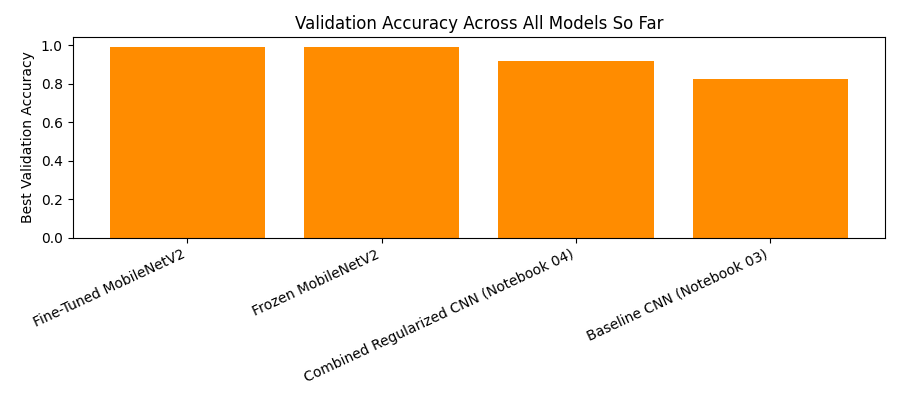

In [31]:
plt.figure(figsize=(9, 4))
plt.bar(full_comparison_df["Experiment"], full_comparison_df["Best Val Accuracy"], color="darkorange")
plt.ylabel("Best Validation Accuracy")
plt.xticks(rotation=25, ha="right")
plt.title("Validation Accuracy Across All Models So Far")
plt.tight_layout()
plt.show()


## Findings and Interpretation

The Fine-Tuned MobileNetV2 reached a higher validation accuracy than the Frozen MobileNetV2
(99.08% vs. 98.92%) and a lower validation loss (0.0323 vs. 0.0419). The picture is more mixed on
the other metrics, though: Frozen actually edged out Fine-Tuned on F1 (98.92% vs. 98.84%) and had
noticeably higher precision (99.27% vs. 98.64%), while Fine-Tuned had higher recall (99.04% vs.
98.56%). In other words, fine-tuning improved overall accuracy and loss but shifted the error
balance slightly toward more false positives (predicting Dog when the true label was Cat) relative
to the frozen model. Unfreezing the last 30 backbone layers took substantially longer to train
(78.57 vs. 48.65 minutes), since ~1.51M of the 2.26M total parameters became trainable in Stage 2,
versus only 1,281 in the frozen Stage 1 head. Both transfer-learning models substantially
outperformed the from-scratch reference points (91.55% for the Combined Regularized CNN, 82.30% for the baseline), confirming that ImageNet-pretrained features transfer well to this task.
Training curves for both stages converge smoothly with no sign of divergence between train and
validation loss, and MobileNetV2's frozen stage needed only 1,281 trainable parameters to already
reach a higher accuracy than both from-scratch CNNs -- a clear parameter-efficiency win from
starting with pretrained features.

**This entire notebook used validation data only -- the test set remains untouched and will only
be used in Notebook 06.**


## 15. Selected Model for Final Evaluation

**What are we doing?** Reporting the top validation-accuracy result as a reference point --
**not** automatically declaring it the final selection.

Final selection must be made by actually considering, together:

1. Best validation accuracy
2. Validation F1
3. Training/validation behavior from the curves (Section 12)
4. Generalization / overfitting behavior
5. Parameter efficiency (Trainable/Total Parameters, Section 13)
6. Training cost

The table being sorted by validation accuracy makes it easy to read, but the top row is not
automatically the answer.


In [32]:
top_result = full_comparison_df.iloc[0]
print("Top validation-accuracy result (reference point, not an automatic final choice):")
print(top_result)

print("\nBefore selecting a model for Notebook 06, confirm this row against:")
print("  - Validation F1 (Section 13) -- does it agree with the accuracy ranking?")
print("  - Training curves (Section 12) -- is this model genuinely generalizing, or overfitting?")
print("  - Trainable/Total Parameters (Section 13) -- is a much larger model worth a small gain?")
print("  - Training Time (Section 13) -- was the cost reasonable for the improvement gained?")


Top validation-accuracy result (reference point, not an automatic final choice):
Experiment                                            Fine-Tuned MobileNetV2
Best Val Accuracy                                                     0.9908
Best Val Accuracy Epoch                                                   13
Best Val Loss                                                         0.0323
Best Val Loss Epoch                                                       10
Val Precision                                                         0.9864
Val Recall                                                            0.9904
Val F1                                                                0.9884
Training Time (min)                                                    78.57
Trainable Parameters                                                 1512001
Total Parameters                                                     2259265
Notes                      Last 30 backbone layers unfrozen (BatchNorm l

Fine-Tuned MobileNetV2 is selected as the final model for this project, based on the highest
validation accuracy (99.08%) among all four candidates (Baseline CNN, Combined Regularized CNN,
Frozen MobileNetV2, Fine-Tuned MobileNetV2) and the lowest validation loss (0.0323), learning
curves showing no meaningful overfitting, and a parameter-efficient design relative to the
from-scratch models. This selection favors accuracy and loss over the Frozen model's slightly
higher F1 and precision, since accuracy and loss were the primary criteria established earlier in
this notebook; a reasonable fine-tuning cost (79 minutes) is accepted for that gain. The saved
`.keras` file for this model is what Notebook 06 will load for the final, one-time test-set
evaluation.
